<a href="https://colab.research.google.com/github/nightfox133/Java-projects/blob/main/FEMMES_AI_Workshop1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Below are the packages needed for this exercise. You do not need to edit the codeblock below (just click run!)

In [10]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

Fill in the code to read the dataSetHorseshoes.csv using pandas. Feel free to search up how to do this, as we don't expect you to know it.

In [13]:
df = pd.read_csv('/dataSetHorseshoes.csv')

X = df.iloc[:, 1:]  #the second and third cols are features - this code is saying X = everything after first col
y = df.iloc[:, 0]   #first col is the target

MessageError: Error: credential propagation was unsuccessful

Below is the code to train the decision tree. You will be running this code several times to:
1. Create a fully grown tree (this means there's no max depth)
2. Create a tree that you think has the optimal depth
3. Create a tree that you think is too shallow

For 2 & 3, note down the depth you used so that we can discuss together. You may need to run this code more than 3 times as you test different depths.

In [19]:
clf = DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=5,             #TODO - edit this line
    random_state=42
)

clf.fit(X, y)            #TODO - add the code to fit the model. feel free to search up the clf function

DecisionTreeClassifier(max_depth=5, random_state=42)

Below is the code for visualizing the tree. You do not need to edit anything below except the title of the plot.

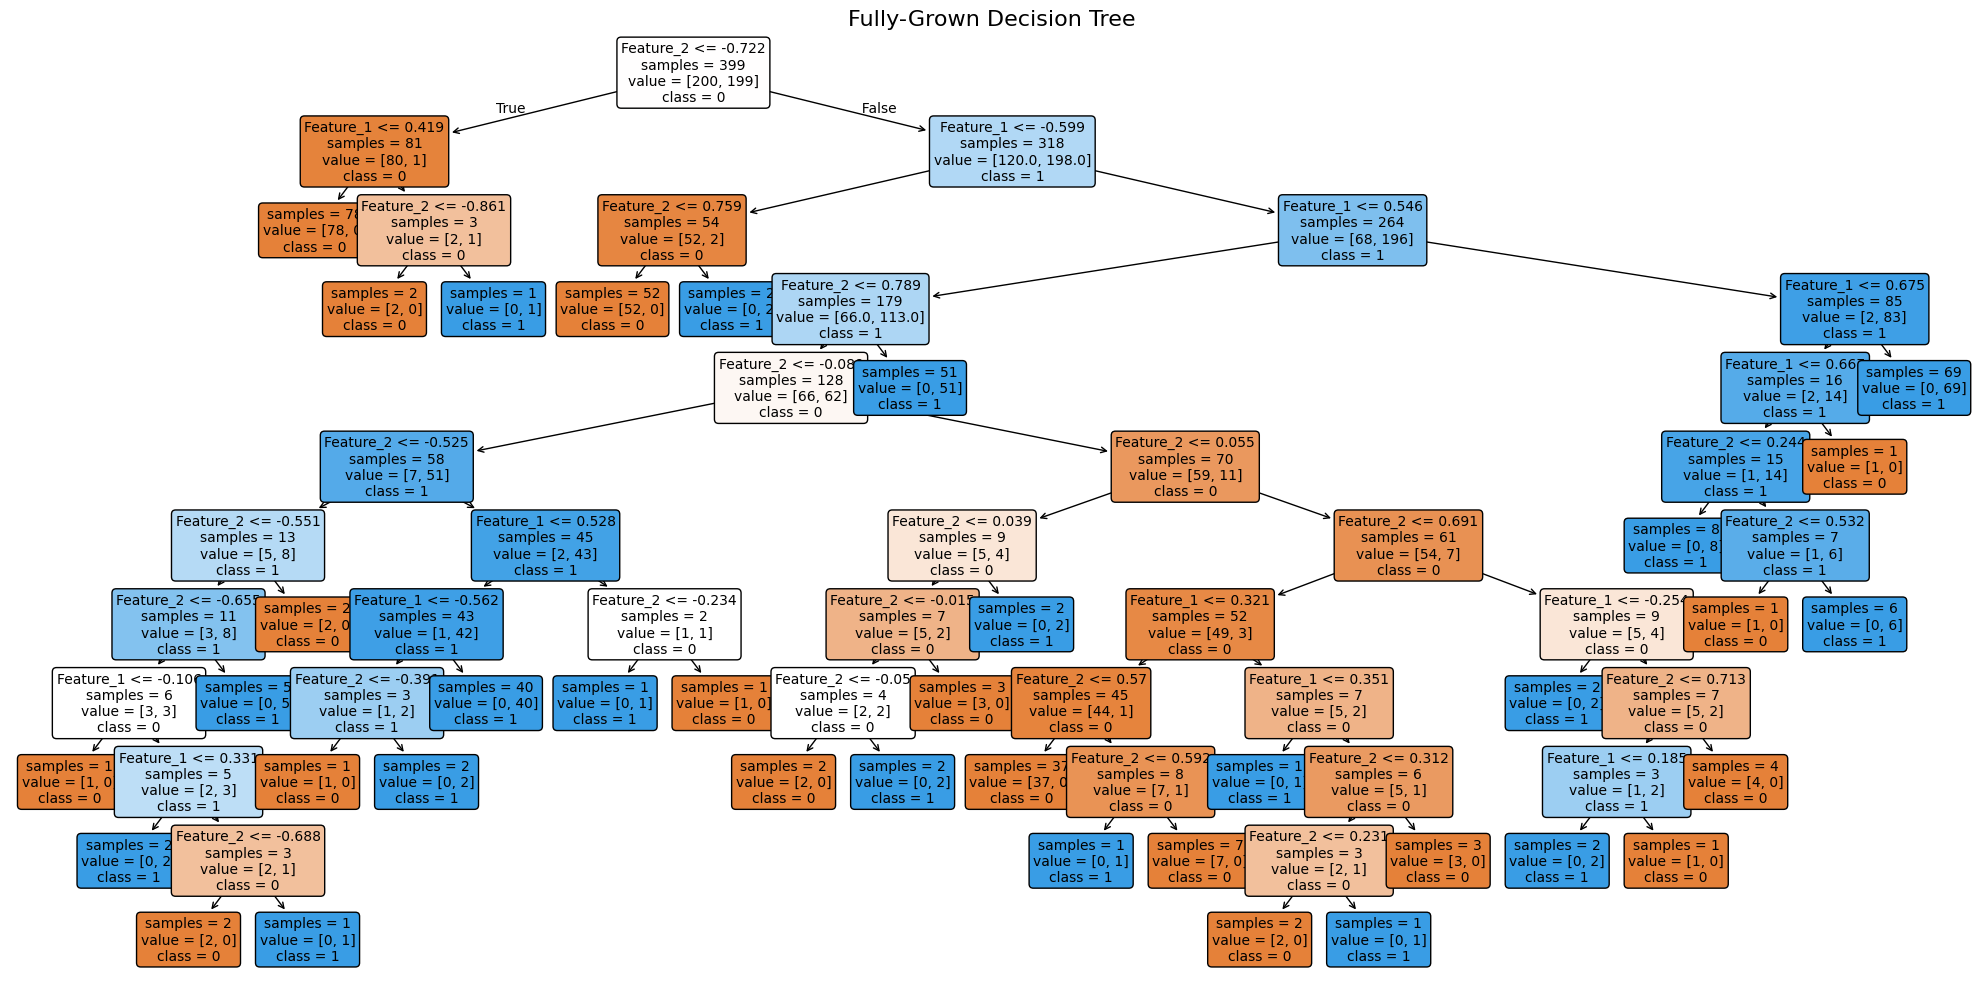

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=[f'Feature_{i+1}' for i in range(X.shape[1])],
          class_names=[str(c) for c in clf.classes_],
          filled=True,
          rounded=True,
          impurity=False,
          proportion=False,
          fontsize=10)
plt.title("Fully-Grown Decision Tree", fontsize=16) #TODO: change this title depending on which tree you are visualizing.
plt.tight_layout()
plt.show()

Below is the code to visualize the decision statistic surface, which displays how the points are classified and where the decision boundary is. Don't worry if you don't fully understand the code below.

Fill in the two missing numbers below. As a hint, both are the same number, and they represent the predicted probability of a point being class 1 at the decision boundary. At the the decision boundary, the prediction flips from class 0 to class 1. Feel free to ask us for help if you are unsure.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


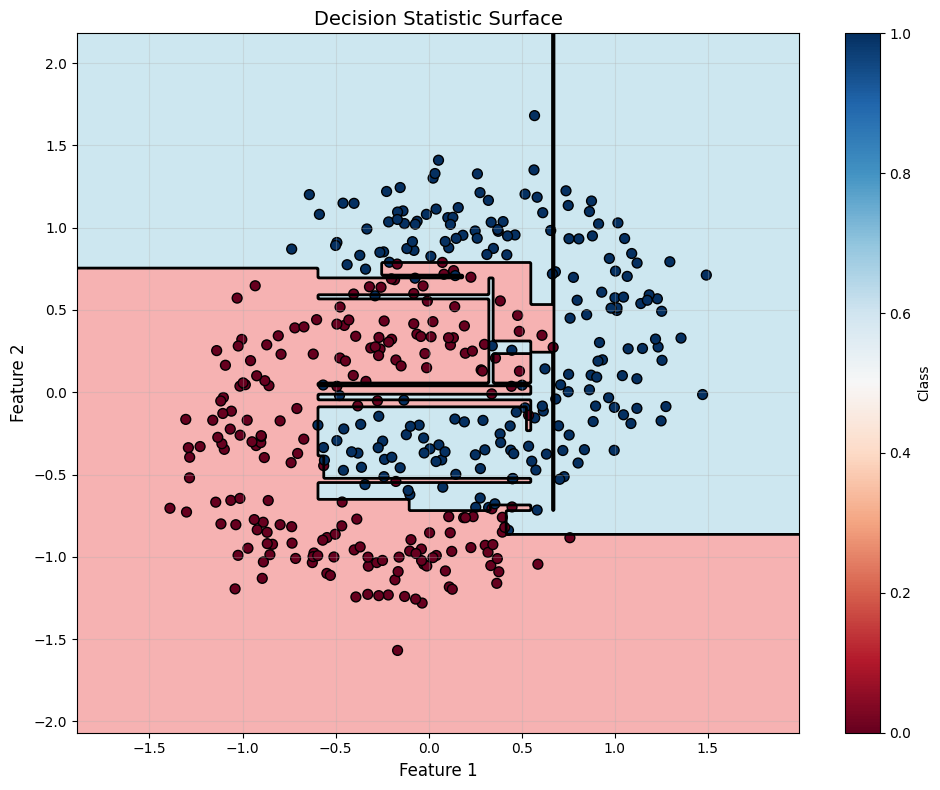

In [17]:
#create a mesh grid
x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

#predict probabilities for each point in the mesh
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
contourf = plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['lightcoral','lightblue'], alpha=0.6) #TODO

#decision boundary is where probability = ??
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2) #TODO

#plot training data
scatter = plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='RdBu', edgecolors='black', s=50)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Decision Statistic Surface', fontsize=14)
plt.colorbar(scatter, label='Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()